# Unrotated $Z_1 Z_2 Z_3 X_4$ Joint Lattice Surgery (no bend)

Four-patch mixed-Pauli joint measurement on the **unrotated** surface code, **straight
(no bend)** — the same domain-wall method as `routed_ZX_LS.ipynb`, generalized to 4 patches.

**Method**: a multi-patch coupler on a straight vertical corridor measures the all-$X$
product $X_1X_2X_3X_4$ (with `#logical = 4-1 = 3`).  Then **rotate the three $Z$-target
patches** ($p1,p2,p3$) by re-typing their stabilizers (swap $X\leftrightarrow Z$ on their
data).  The coupler checks touching a rotated patch become **MIXED** domain-wall checks;
the joint measured operator becomes $Z_1Z_2Z_3X_4$.

**Verified**: stabilizer algebra (`#logical=3`, joint $=Z_1Z_2Z_3X_4$, no proper
sub-product measured, mixed checks present, all commute) **and** a syndrome-extraction
circuit that genuinely measures the mixed checks (DEM-valid + noiseless +
`detecting_regions` shows instantaneous mixed data checks).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle, Rectangle
import matplotlib.patches as mpatches

from lightstim.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode, UnrotatedSurfaceCodeExtractionBlock, UnrotatedMultiPatchCoupler)
from lightstim.ir.qec_system import QECSystem
from lightstim.ir.builder import CircuitBuilder
from lightstim.ir.tracker import SyndromeTracker
from lightstim.protocols.routed_multi_patch_ls import (
    logical_pauli_product_vector, _coupler_on_active_stabilizer_uids)
from lightstim.utils.tableau_utils import stabilizers_to_symplectic

NAMES = ['p1', 'p2', 'p3', 'p4']
LAYOUT = [('p1', (0, 0)), ('p2', (10, 0)), ('p3', (0, 12)), ('p4', (10, 12))]
ROT = ('p1', 'p2', 'p3')           # rotate the three Z-target patches (X->Z)
SW = {'X': 'Z', 'Z': 'X'}

def gf2_rank(rows):
    M = np.array([r.copy() for r in rows], np.uint8); r = 0
    for c in range(M.shape[1]):
        piv = next((k for k in range(r, M.shape[0]) if M[k, c]), None)
        if piv is None:
            continue
        M[[r, piv]] = M[[piv, r]]
        for k in range(M.shape[0]):
            if k != r and M[k, c]:
                M[k] ^= M[r]
        r += 1
    return r

def in_span(rows, t):
    return gf2_rank(list(rows) + [t]) == gf2_rank(list(rows))

def build_zzzx():
    system = QECSystem()
    for n, off in LAYOUT:
        system.add_patch(UnrotatedSurfaceCode(distance=3), name=n, offset=off)
    system.register_coupler(UnrotatedMultiPatchCoupler(), NAMES, 'c', path_axis='vertical', center_axis=7.0)
    system.activate_coupler('c')
    rot_data = {q for q in system.data_indices if system.index_to_owner_map.get(q) in ROT}
    for s in system.stabilizers:            # rotate p1,p2,p3 by re-typing: swap X<->Z on their data
        s['pauli'] = {q: (SW[P] if q in rot_data else P) for q, P in s['pauli'].items()}
        ts = set(s['pauli'].values())
        s['type'] = 'MIXED' if {'X', 'Z'} <= ts else ('X' if ts == {'X'} else 'Z')
    return system, rot_data

system, rot_data = build_zzzx()
N = system.num_qubits
def hconj(v):                               # swap X<->Z on the rotated data (frame of the rotation)
    v = v.copy()
    for q in rot_data:
        v[[q, N + q]] = v[[N + q, q]]
    return v
print('built 4 patches + straight vertical coupler; rotated p1,p2,p3 (X->Z)')

built 4 patches + straight vertical coupler; rotated p1,p2,p3 (X->Z)


In [2]:
# ---- stabilizer-algebra verification ----
recs = [system.stabilizers[u] for u in sorted(_coupler_on_active_stabilizer_uids(system, 'c'))]
S = stabilizers_to_symplectic(system, recs, N)
ndata = len(system.data_indices); rank = gf2_rank(list(S)); nlog = ndata - rank
bad = sum(1 for i in range(len(S)) for j in range(i + 1, len(S))
          if int((S[i][:N] & S[j][N:]).sum() + (S[i][N:] & S[j][:N]).sum()) % 2)
nmixed = len(system.active_stabilizers_mixed)

joint = hconj(logical_pauli_product_vector(system, NAMES, ['X', 'X', 'X', 'X'])[0])  # = Z1Z2Z3X4
def rotated(ps):
    v = np.zeros(2 * N, np.uint8)
    for name, p in zip(NAMES, ps):
        if p == 'I':
            continue
        base = logical_pauli_product_vector(system, [name], ['X'])[0]
        v ^= (hconj(base) if name in ROT else base)
    return v
subs = {'Z1': ['Z','I','I','I'], 'X4': ['I','I','I','X'], 'Z1Z2': ['Z','Z','I','I'],
        'Z1Z2Z3': ['Z','Z','Z','I'], 'Z2Z3X4': ['I','Z','Z','X']}
sub_measured = {k: in_span(S, rotated(v)) for k, v in subs.items()}

print(f'(1) data={ndata}, rank={rank}, #logical={nlog}   (4 patches -> expect 3)')
print(f'    all stabilizers commute        : {bad == 0}  (anticommuting pairs={bad})')
print(f'(2) joint  Z1*Z2*Z3*X4 measured    : {in_span(S, joint)}')
print(f'    any proper sub-product measured: {any(sub_measured.values())}   {sub_measured}')
print(f'(3)/(4) MIXED domain-wall checks    : {nmixed}')
PASS = (bad == 0 and nlog == 3 and in_span(S, joint) and not any(sub_measured.values()) and nmixed > 0)
print(f'\nALGEBRA PASS = {PASS}')
assert PASS

(1) data=94, rank=91, #logical=3   (4 patches -> expect 3)
    all stabilizers commute        : True  (anticommuting pairs=0)
(2) joint  Z1*Z2*Z3*X4 measured    : True
    any proper sub-product measured: False   {'Z1': False, 'X4': False, 'Z1Z2': False, 'Z1Z2Z3': False, 'Z2Z3X4': False}
(3)/(4) MIXED domain-wall checks    : 15

ALGEBRA PASS = True


In [3]:
# ---- the MIXED domain-wall checks (one seam per rotated patch) ----
coords = {q: tuple(system.qubit_coords[q]) for q in range(N)}
print(f'{nmixed} MIXED checks (X-side / Z-side):')
by_owner = {}
for s in system.active_stabilizers_mixed:
    xs = sorted(coords[q] for q, P in s['pauli'].items() if P == 'X')
    zs = sorted(coords[q] for q, P in s['pauli'].items() if P == 'Z')
    by_owner.setdefault(round(s['syn_coord'][1] // 12), []).append((s['syn_coord'], xs, zs))
for s in system.active_stabilizers_mixed:
    xs = sorted(coords[q] for q, P in s['pauli'].items() if P == 'X')
    zs = sorted(coords[q] for q, P in s['pauli'].items() if P == 'Z')
    print(f"  @ {s['syn_coord']}:  X@{xs}  Z@{zs}")

15 MIXED checks (X-side / Z-side):
  @ (5.0, 0.0):  X@[(5.0, 1.0), (6.0, 0.0)]  Z@[(4, 0.0)]
  @ (9.0, 0.0):  X@[(8.0, 0.0), (9.0, 1.0)]  Z@[(10.0, 0.0)]
  @ (5.0, 2.0):  X@[(5.0, 1.0), (5.0, 3.0), (6.0, 2.0)]  Z@[(4, 2)]
  @ (9.0, 2.0):  X@[(8.0, 2.0), (9.0, 1.0), (9.0, 3.0)]  Z@[(10.0, 2)]
  @ (5.0, 4.0):  X@[(5.0, 3.0), (5.0, 5.0), (6.0, 4.0)]  Z@[(4, 4)]
  @ (9.0, 4.0):  X@[(8.0, 4.0), (9.0, 3.0), (9.0, 5.0)]  Z@[(10.0, 4)]
  @ (5.0, 12.0):  X@[(5.0, 11.0), (5.0, 13.0), (6.0, 12.0)]  Z@[(4, 12.0)]
  @ (5.0, 14.0):  X@[(5.0, 13.0), (5.0, 15.0), (6.0, 14.0)]  Z@[(4, 14)]
  @ (5.0, 16.0):  X@[(5.0, 15.0), (6.0, 16.0)]  Z@[(4, 16)]
  @ (4, 1):  X@[(3, 1), (4, 0.0), (4, 2)]  Z@[(5.0, 1.0)]
  @ (4, 3):  X@[(3, 3), (4, 2), (4, 4)]  Z@[(5.0, 3.0)]
  @ (4, 13):  X@[(3, 13), (4, 12.0), (4, 14)]  Z@[(5.0, 13.0)]
  @ (4, 15):  X@[(3, 15), (4, 14), (4, 16)]  Z@[(5.0, 15.0)]
  @ (10.0, 1):  X@[(10.0, 0.0), (10.0, 2), (11, 1)]  Z@[(9.0, 1.0)]
  @ (10.0, 3):  X@[(10.0, 2), (10.0, 4), (11, 3)]  Z@[

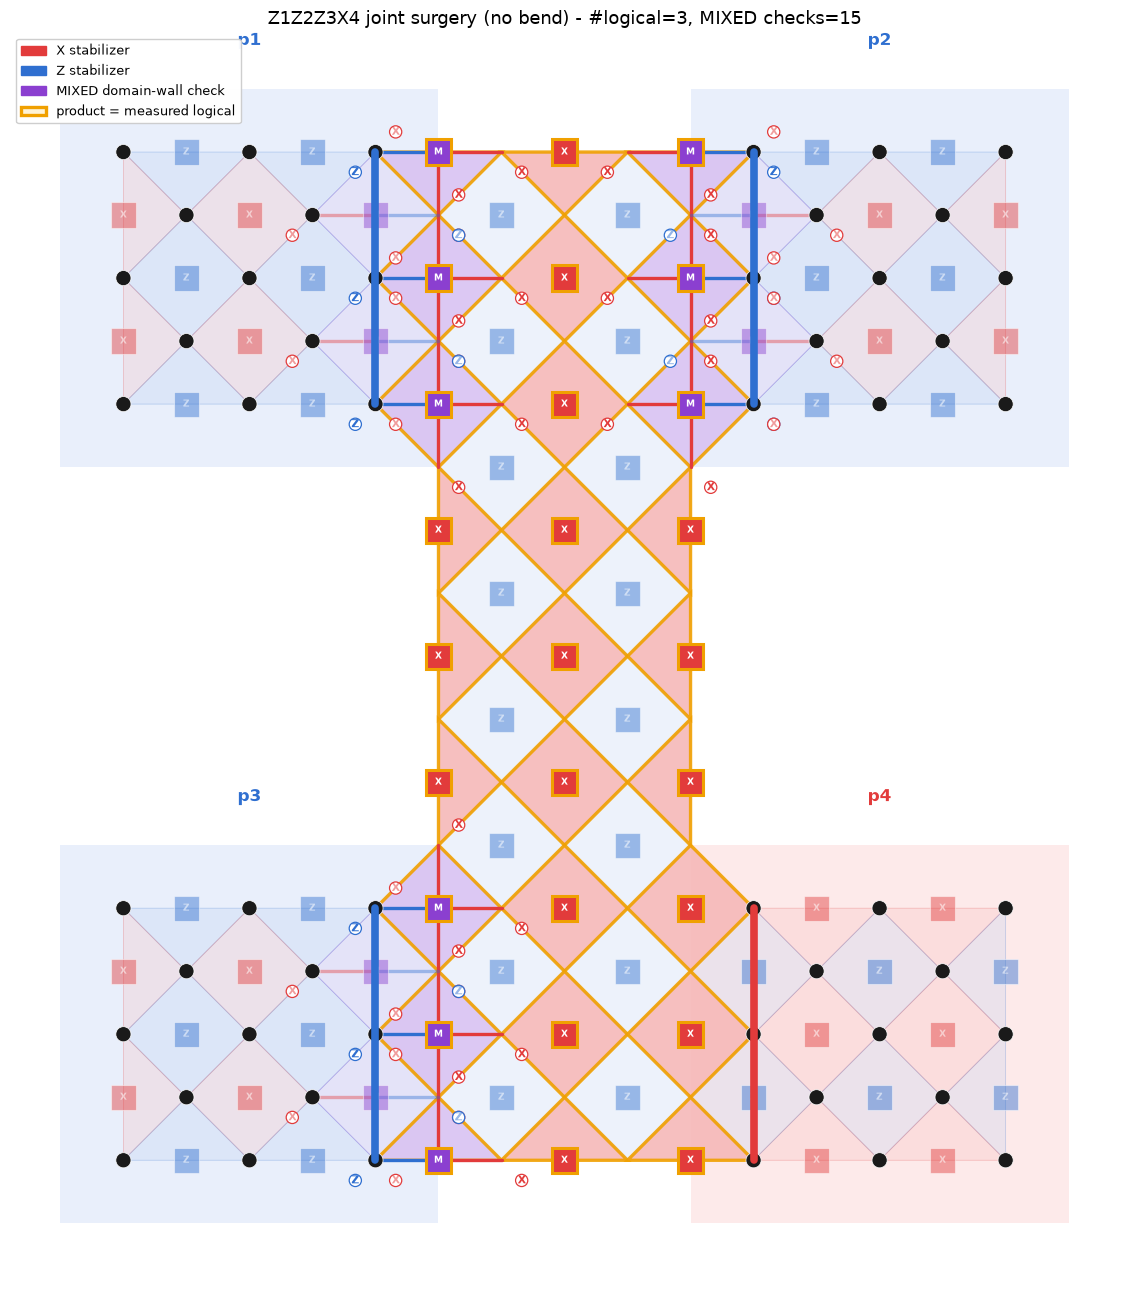

In [4]:
# ---- visualize; highlight the stabilizers whose product = the measured Z1Z2Z3X4 ----
from lightstim.utils.linear_algebra import solve_linear_decomposition
COL = {'X': '#e23b3b', 'Z': '#2f6fd0', 'MIXED': '#8b3fd0'}; FILL = {'X': '#f6b8b8', 'Z': '#b8cdf0', 'MIXED': '#d9c2f2'}
GOLD = '#f0a000'
patches = {n: system.patches[n][0] for n in NAMES}
target = {'p1': 'Z', 'p2': 'Z', 'p3': 'Z', 'p4': 'X'}

def _svN(pauli):
    v = np.zeros(2 * N, np.uint8)
    for q, P in pauli.items():
        if P in ('X', 'Y'): v[q] ^= 1
        if P in ('Z', 'Y'): v[N + q] ^= 1
    return v
# target = the measured logical on each patch's CORRIDOR-FACING edge (the drawn lines),
# so the highlighted product stays on the seam/corridor checks (no patch-interior checks).
_g_of = {c: q for q, c in coords.items()}
_tgt = np.zeros(2 * N, np.uint8)
for _n in NAMES:
    _p = patches[_n]; _tp = target[_n]
    _fx = min({_p.qubit_coords[q][0] for q in _p.data_indices}, key=lambda x: abs(x - 7))
    for q in _p.data_indices:
        _c = tuple(_p.qubit_coords[q])
        if abs(_c[0] - _fx) < 1e-9:
            if _tp == 'X': _tgt[_g_of[_c]] ^= 1
            else: _tgt[N + _g_of[_c]] ^= 1
_co, _dep, _ = solve_linear_decomposition(
    basis=np.array([_svN(s['pauli']) for s in recs], np.uint8),
    targets=_tgt.reshape(1, -1), reduce_weight=True)
HL = set(np.where(_co[0])[0]) if _dep[0] else set()

fig, ax = plt.subplots(figsize=(12, 13))
for n in NAMES:
    p = patches[n]; x0, x1, y0, y1 = p._get_bounds()
    ax.add_patch(Rectangle((x0 - 1, y0 - 1), (x1 - x0) + 2, (y1 - y0) + 2,
                 facecolor='#fdeaea' if target[n] == 'X' else '#e9effb', ec='none', zorder=0))
    ax.text((x0 + x1) / 2, y0 - 1.7, n, ha='center', fontweight='bold', color=COL[target[n]], fontsize=12)

for i, s in enumerate(recs):
    hl = i in HL; a = 0.9 if hl else 0.25
    syn = s['syn_coord']; t = s['type']; pauli = s['pauli']; pts = [coords[q] for q in pauli]
    if len(pts) >= 3:
        cx, cy = np.mean([q[0] for q in pts]), np.mean([q[1] for q in pts])
        order = sorted(pts, key=lambda q: np.arctan2(q[1] - cy, q[0] - cx))
        ax.add_patch(Polygon(order, closed=True, facecolor=FILL[t], edgecolor=(GOLD if hl else COL[t]),
                     lw=(2.4 if hl else 0.6), alpha=a, zorder=(3 if hl else 2)))
    elif len(pts) == 2:
        (a1, b1), (c1, d1) = pts
        ax.plot([a1, syn[0], c1], [b1, syn[1], d1], color=(GOLD if hl else COL[t]), lw=(7 if hl else 6),
                alpha=(0.7 if hl else 0.25), solid_capstyle='round', zorder=(3 if hl else 2))
    if t == 'MIXED':
        for q, P in pauli.items():
            c = coords[q]
            ax.plot([syn[0], c[0]], [syn[1], c[1]], color=COL[P], lw=2.4, zorder=5, alpha=(1 if hl else 0.4), solid_capstyle='round')
            ox = 0.32 if c[0] >= syn[0] else -0.32; oy = 0.32 if c[1] >= syn[1] else -0.32
            ax.text(c[0] + ox, c[1] + oy, P, color=COL[P], fontsize=8, fontweight='bold', ha='center', va='center',
                    zorder=9, alpha=(1 if hl else 0.5), bbox=dict(boxstyle='circle,pad=0.05', fc='white', ec=COL[P], lw=0.9))
    ax.add_patch(Rectangle((syn[0] - 0.2, syn[1] - 0.2), 0.4, 0.4, facecolor=COL[t],
                 edgecolor=(GOLD if hl else 'white'), lw=(2.2 if hl else 0.8), zorder=6, alpha=(1 if hl else 0.45)))
    ax.text(syn[0], syn[1], 'M' if t == 'MIXED' else t, ha='center', va='center', fontsize=6.5,
            color='white', fontweight='bold', zorder=7, alpha=(1 if hl else 0.55))

for n in NAMES:
    for q in patches[n].data_indices:
        ax.add_patch(Circle(tuple(patches[n].qubit_coords[q]), 0.12, facecolor='#1a1a1a', edgecolor='white', lw=0.5, zorder=8))
for n in NAMES:
    p = patches[n]; tp = target[n]
    fx = min({p.qubit_coords[q][0] for q in p.data_indices}, key=lambda x: abs(x - 7))
    col = sorted(tuple(p.qubit_coords[q]) for q in p.data_indices if p.qubit_coords[q][0] == fx)
    ax.plot([c[0] for c in col], [c[1] for c in col], color=COL[tp], lw=5.5, zorder=10, solid_capstyle='round')
    lbl = (r'$\bar X_%s$' % n[-1]) if tp == 'X' else (r'$\bar Z_%s$' % n[-1])
    ax.text(fx + (1.0 if fx < 7 else -1.0), np.mean([c[1] for c in col]), lbl,
            color=COL[tp], fontsize=13, fontweight='bold', ha='center', va='center')
handles = [mpatches.Patch(color=COL['X'], label='X stabilizer'), mpatches.Patch(color=COL['Z'], label='Z stabilizer'),
           mpatches.Patch(color=COL['MIXED'], label='MIXED domain-wall check'),
           mpatches.Patch(facecolor='#fff3d6', edgecolor=GOLD, lw=2.4, label='product = measured logical')]
ax.legend(handles=handles, loc='upper left', fontsize=9, framealpha=0.96)
ax.set_title(f'Z1Z2Z3X4 joint surgery (no bend) - #logical={nlog}, MIXED checks={nmixed}', fontsize=13)
ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off'); plt.tight_layout(); plt.show()

---
## Circuit-level syndrome extraction

Same as the $X_1Z_2$ notebook: rotate $p1,p2,p3$ by **re-typing** their stabilizers
(swap $X\leftrightarrow Z$ on their data) so the coupler checks touching them become
genuine **MIXED** checks, measured by the SE block's mixed-check extraction (X-basis
ancilla, `CNOT`/`CZ`).  Acceptance: `assert_dem_valid` + `assert_noiseless` + a
`detecting_regions` check that the circuit really measures instantaneous mixed data checks.

In [5]:
def build_zzzx_circuit(rounds=2, init_basis='Z', coupler_init='X'):
    system = QECSystem()
    for n, off in LAYOUT:
        system.add_patch(UnrotatedSurfaceCode(distance=3), name=n, offset=off)
    system.register_coupler(UnrotatedMultiPatchCoupler(), NAMES, 'c', path_axis='vertical', center_axis=7.0)
    cp = system.coupler_patches['c']
    rot = {q for q in system.data_indices if system.index_to_owner_map.get(q) in ROT}
    for s in system.stabilizers:
        s['pauli'] = {q: (SW[P] if q in rot else P) for q, P in s['pauli'].items()}
        ts = set(s['pauli'].values())
        s['type'] = 'MIXED' if {'X', 'Z'} <= ts else ('X' if ts == {'X'} else 'Z')
    tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=system.num_logicals)
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    builder.write_coordinates()
    nc = {q: init_basis for q in system.data_indices if system.index_to_owner_map[q] != 'c'}
    builder.initialize(init_dict=nc, n=system.num_qubits)
    builder.apply_syndrome_extraction(circuit_chunk=UnrotatedSurfaceCodeExtractionBlock(system).circuit, rounds=rounds)
    builder.activate_coupler('c')
    builder.initialize(init_dict={system.local_to_global_map['c'][q]: coupler_init for q in cp.data_indices}, n=system.num_qubits)
    builder.apply_syndrome_extraction(circuit_chunk=UnrotatedSurfaceCodeExtractionBlock(system).circuit, rounds=rounds)
    builder.apply_data_readout(final_measurements=nc)
    return builder.circuit, system

circuit, circ_system = build_zzzx_circuit(rounds=2)
print(f'circuit: qubits={circuit.num_qubits} detectors={circuit.num_detectors} observables={circuit.num_observables}')
print(f'active MIXED stabilizers measured: {len(circ_system.active_stabilizers_mixed)}')

circuit: qubits=185 detectors=240 observables=3
active MIXED stabilizers measured: 15


In [6]:
dem = circuit.flattened().detector_error_model(decompose_errors=True)
dem_ok = (dem.num_detectors == circuit.num_detectors and dem.num_observables == circuit.num_observables)
dets, obs = circuit.compile_detector_sampler(seed=42).sample(shots=200, separate_observables=True)
noiseless_ok = (not dets.any()) and (not obs.any())
DATA = set(circ_system.data_indices)
n_mixed = 0
for det, ticks in circuit.detecting_regions().items():
    for ps in ticks.values():
        xs = [i for i in range(len(ps)) if ps[i] == 1 and i in DATA]
        zs = [i for i in range(len(ps)) if ps[i] == 3 and i in DATA]
        ys = [i for i in range(len(ps)) if ps[i] == 2 and i in DATA]
        if xs and zs and not ys:
            n_mixed += 1; break
print(f'DEM valid                              : {dem_ok}')
print(f'noiseless 200 shots: det={int(dets.sum())}, logical_errors={int(obs.sum())}')
print(f'detectors measuring an instantaneous MIXED data check: {n_mixed}')
print(f'\nCIRCUIT ACCEPTANCE PASS = {dem_ok and noiseless_ok and n_mixed > 0}')
assert dem_ok and noiseless_ok and n_mixed > 0

DEM valid                              : True
noiseless 200 shots: det=0, logical_errors=0
detectors measuring an instantaneous MIXED data check: 15

CIRCUIT ACCEPTANCE PASS = True


## Circuit diagram (`detslice-with-ops-svg`)

In [7]:
circuit.diagram("detslice-with-ops-svg")

## Summary

Straight (no-bend) unrotated $Z_1Z_2Z_3X_4$ joint measurement, verified:

| | result |
| --- | --- |
| `#logical` (4 patches, 1 joint) | 3 |
| joint $Z_1Z_2Z_3X_4$ measured; no proper sub-product | ✓ |
| MIXED domain-wall checks (one seam per rotated patch) | ✓ |
| circuit: DEM-valid + noiseless + measures the mixed checks | ✓ |

**Next:** the bent-bus geometry, and circuit-level FT (hook-error) scheduling.